In [49]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, classification_report
import warnings
warnings.filterwarnings("ignore")

# =========================
# 1️⃣ Paramètres
# =========================

TARGET = "target_is_fraud"
ID_COL = "customer_id"
THRESHOLD = 0.704

# =========================
# 2️⃣ Chargement des données
# =========================

train = pd.read_csv("../6.Data/Yann_Process_train.csv")
test  = pd.read_csv("../6.Data/Yann_Process_test.csv")

# =========================
# 3️⃣ Feature engineering
# =========================

def build_features(df):
    df = df.copy()
    
    df["ip_risk_minus_device_trust"] = df["ip_risk_z"] - df["device_trust_z"]
    
    df["raw_risk_score"] = (
        df["chargebacks_12m"].clip(lower=0)
        + df["failed_payments_6m"].clip(lower=0)
        + df["ip_risk_z"].clip(lower=0)
        + df["support_tickets_90d"].clip(lower=0)
        - df["device_trust_z"].clip(upper=0)
    )
    
    df["cb_per_tenure"] = df["chargebacks_12m"] / (df["tenure_months"].abs() + 0.1)
    df["vpn_x_ip_risk"] = df["is_vpn"] * df["ip_risk_z"]
    df["devices_x_vpn"] = df["num_devices_30d"] * df["is_vpn"]
    df["cb_x_failed"]   = df["chargebacks_12m"] * df["failed_payments_6m"]
    
    return df

train = build_features(train)
test  = build_features(test)

# =========================
# 4️⃣ Features
# =========================

FEATURES = [
    "ip_risk_minus_device_trust",
    "ip_risk_z",
    "tenure_months",
    "raw_risk_score",
    "is_vpn",
    "cb_per_tenure",
    "vpn_x_ip_risk",
    "failed_payments_6m",
    "num_devices_30d",
    "devices_x_vpn",
    "support_tickets_90d",
]

X = train[FEATURES]
y = train[TARGET]
X_test = test[FEATURES]

# =========================
# 5️⃣ Cross Validation 5-Fold
# =========================



dico = {}
for estimator in [800]:
    for depth in [1,2,3,4,5,6,7,8]:
            for learning_rate in [0.02,0.1]:

                skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

                f1_scores = []

                for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
                    
                    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
                    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
                    
                    model = xgb.XGBClassifier(
                        n_estimators=estimator,
                        max_depth=depth,
                        learning_rate=learning_rate,
                        scale_pos_weight=10.6,
                        subsample=0.8,
                        colsample_bytree=0.8,
                        eval_metric="aucpr",
                        random_state=42,
                        n_jobs=-1,
                    )
                    
                    model.fit(X_train, y_train, verbose=False)
                    
                    y_prob = model.predict_proba(X_val)[:, 1]
                    y_pred = (y_prob >= THRESHOLD).astype(int)
                    
                    f1 = f1_score(y_val, y_pred)
                    f1_scores.append(f1)
                    
                    #print(f"Fold {fold+1} - F1 : {f1:.4f}")

                print("\n======================")
                print(f"Params : n_estimators={estimator}, max_depth={depth}, learning_rate={learning_rate}")
                print(f"F1 moyen (5 folds) : {np.mean(f1_scores):.4f}")
                print(f"Écart-type         : {np.std(f1_scores):.4f}")
                dico[(estimator, depth, learning_rate)] = np.mean(f1_scores)
                print("======================\n")

                # =========================
                # 6️⃣ Entraînement final sur tout le train
                # =========================

                final_model = xgb.XGBClassifier(
                    n_estimators=600,
                    max_depth=10,
                    learning_rate=0.1,
                    scale_pos_weight=10.6,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    eval_metric="aucpr",
                    random_state=42,
                    n_jobs=-1,
                )

                final_model.fit(X, y)

# # =========================
# # 7️⃣ Feature Importance (GAIN)
# # =========================

# booster = final_model.get_booster()
# importance_dict = booster.get_score(importance_type="gain")

# importance_df = pd.DataFrame({
#     "feature": importance_dict.keys(),
#     "importance_gain": importance_dict.values()
# })

# importance_df = importance_df.sort_values(
#     by="importance_gain", ascending=False
# )

# print("Feature Importance (gain) :")
# print(importance_df)




Params : n_estimators=800, max_depth=1, learning_rate=0.02
F1 moyen (5 folds) : 0.4142
Écart-type         : 0.0073


Params : n_estimators=800, max_depth=1, learning_rate=0.1
F1 moyen (5 folds) : 0.4137
Écart-type         : 0.0052


Params : n_estimators=800, max_depth=2, learning_rate=0.02
F1 moyen (5 folds) : 0.4133
Écart-type         : 0.0060


Params : n_estimators=800, max_depth=2, learning_rate=0.1
F1 moyen (5 folds) : 0.4123
Écart-type         : 0.0067


Params : n_estimators=800, max_depth=3, learning_rate=0.02
F1 moyen (5 folds) : 0.4132
Écart-type         : 0.0052


Params : n_estimators=800, max_depth=3, learning_rate=0.1
F1 moyen (5 folds) : 0.4104
Écart-type         : 0.0063


Params : n_estimators=800, max_depth=4, learning_rate=0.02
F1 moyen (5 folds) : 0.4132
Écart-type         : 0.0048


Params : n_estimators=800, max_depth=4, learning_rate=0.1
F1 moyen (5 folds) : 0.4069
Écart-type         : 0.0086


Params : n_estimators=800, max_depth=5, learning_rate=0.02
F1 moyen

In [51]:
best_params = max(dico, key=dico.get)
best_f1 = dico[best_params]

print("Meilleure combinaison :", best_params)
print("Meilleur F1-score :", best_f1)

Meilleure combinaison : (800, 1, 0.02)
Meilleur F1-score : 0.41416049281299916


In [47]:
from collections import defaultdict
import numpy as np

# On récupère le nombre de paramètres dans la clé
n_params = len(next(iter(dico)))

# On crée une liste de dictionnaires pour stocker les scores
scores_par_param = [defaultdict(list) for _ in range(n_params)]

# Remplissage
for params, f1 in dico.items():
    for i, value in enumerate(params):
        scores_par_param[i][value].append(f1)

# Calcul des moyennes
moyennes = []

for i in range(n_params):
    moyennes.append({
        value: np.mean(scores)
        for value, scores in scores_par_param[i].items()
    })

# Affichage
param_names = ["Paramètre 1", "Paramètre 2", "Paramètre 3"]

for i in range(n_params):
    print(f"\nMoyenne F1 pour {param_names[i]} :")
    for value, mean_f1 in sorted(moyennes[i].items()):
        print(value, ":", round(mean_f1, 4))


Moyenne F1 pour Paramètre 1 :
300 : 0.4078
500 : 0.4117
800 : 0.4129
1000 : 0.4128

Moyenne F1 pour Paramètre 2 :
1 : 0.4075
2 : 0.4122
3 : 0.413
4 : 0.4125

Moyenne F1 pour Paramètre 3 :
0.01 : 0.4085
0.02 : 0.4128
0.05 : 0.4126


In [37]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score


TARGET = 'target_is_fraud'
ID_COL = 'customer_id'

train = pd.read_csv('../6.Data/Yann_Process_train.csv')
test  = pd.read_csv('../6.Data/Yann_Process_test.csv')

def build_features(df):
    df = df.copy()
    df['Score_De_Confiance'] = df['ip_risk_z'] - df['device_trust_z']
    df['Score_Risque'] = (
        df['chargebacks_12m'].clip(lower=0)
        + df['failed_payments_6m'].clip(lower=0)
        + df['ip_risk_z'].clip(lower=0)
        + df['support_tickets_90d'].clip(lower=0)
        - df['device_trust_z'].clip(upper=0)
)
    
    df['cb_per_tenure'] = df['chargebacks_12m'] / (df['tenure_months'].abs() + 0.1)
    df['vpn_ip'] = df['is_vpn'] * df['ip_risk_z']
    df['devices_x_vpn'] = df['num_devices_30d'] * df['is_vpn']
    df['nb_chargeback']   = df['chargebacks_12m'] * df['failed_payments_6m']
    return df

train = build_features(train)
test  = build_features(test)

FEATURES = [
    'Score_De_Confiance',
    'ip_risk_z',
    'tenure_months',
    'Score_Risque',
    'is_vpn',
    'cb_per_tenure',
    'vpn_ip',
    'failed_payments_6m',
    'num_devices_30d',
    'devices_x_vpn',
    'support_tickets_90d',
]

X      = train[FEATURES]
y      = train[TARGET]
X_test = test[FEATURES]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)



model = xgb.XGBClassifier(
    n_estimators          = 700,
    max_depth             = 4,
    learning_rate         = 0.02,
    scale_pos_weight      = 10.6,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    eval_metric           = 'aucpr',
    random_state          = 42,
    n_jobs                = -1,
)
model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

THRESHOLD = 0.51
y_prob_val = model.predict_proba(X_val)[:, 1]
y_pred_val = (y_prob_val >= THRESHOLD).astype(int)
repport = classification_report(
    y_val,
    y_pred_val,
    output_dict=True
)

y_test_prob = model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_prob >= THRESHOLD).astype(int)
f1 = f1_score(y_val, y_pred_val)


submission = pd.DataFrame({
    ID_COL:              test[ID_COL],
    'fraud_probability': y_test_prob,
    TARGET:              y_test_pred,
})
cm = confusion_matrix(y_val, y_pred_val)

recall = recall_score(y_val, y_pred_val)
print(f"Recall : {recall:.4f}")

precision = precision_score(y_val, y_pred_val)
print(f"Precision : {precision:.4f}")


print(f"F1-score : {f1:.4f}")
submission.to_csv('../6.Data/submission_v5.csv', index=False)
print(f"Submission -> {submission[TARGET].sum()} fraudes | {submission[TARGET].mean()*100:.2f}% du test")

Recall : 0.7503
Precision : 0.2294
F1-score : 0.3513
Submission -> 11292 fraudes | 28.23% du test


⏳  Chargement des données…
⏳  Entraînement du modèle XGBoost…
✅  Modèle entraîné.
⏳  Calcul des valeurs SHAP…
✅  Valeurs SHAP calculées.
✅  Graphique sauvegardé → shap_dashboard.png


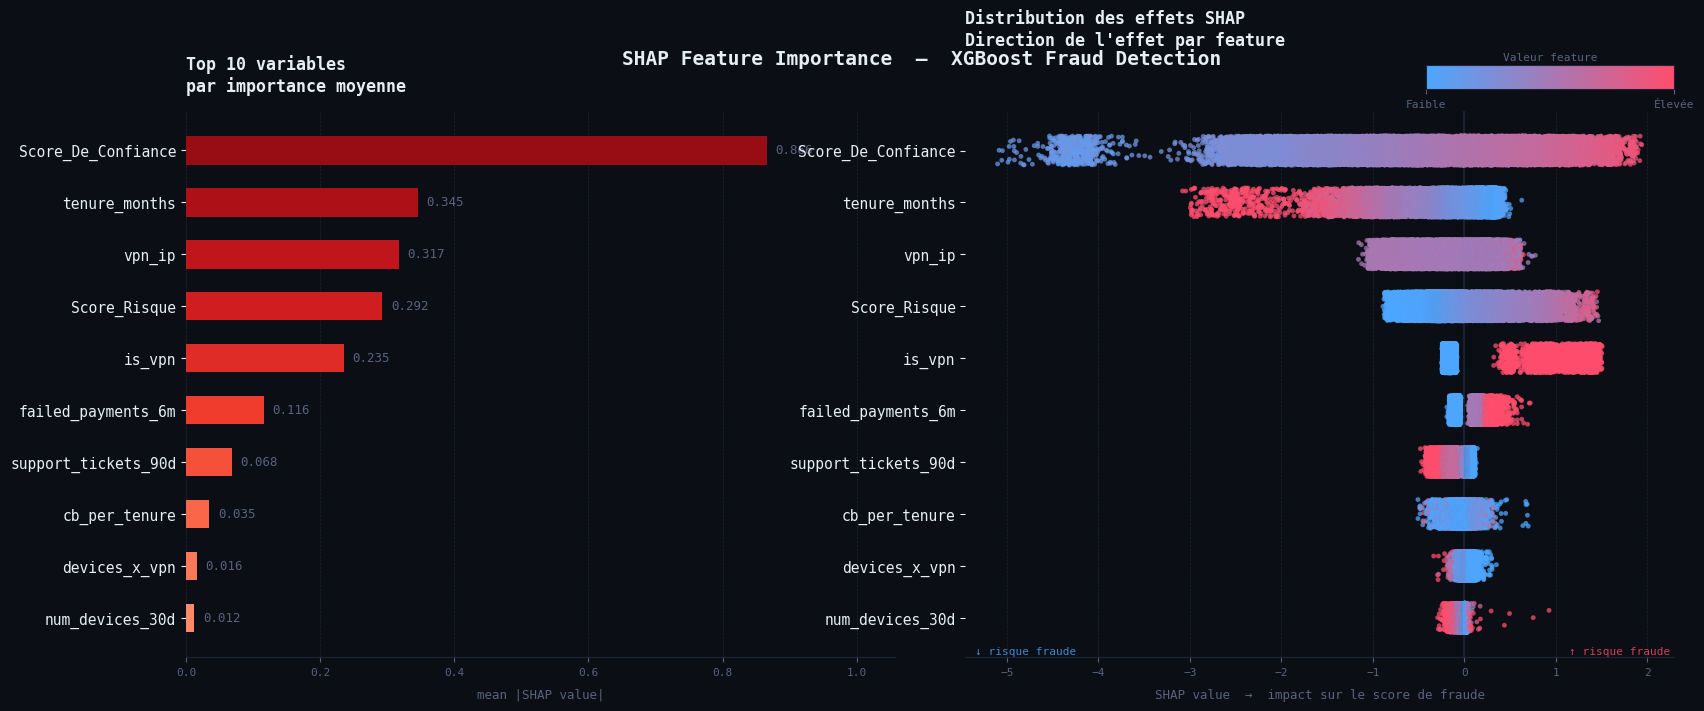

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colorbar import ColorbarBase
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# ── ML ────────────────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
import xgboost as xgb
import shap

# ══════════════════════════════════════════════════════════════════════════════
#  CONFIG  — adapte les chemins à ton projet
# ══════════════════════════════════════════════════════════════════════════════
TRAIN_PATH = '../6.Data/Yann_Process_train.csv'
TEST_PATH  = '../6.Data/Yann_Process_test.csv'
TARGET     = 'target_is_fraud'
ID_COL     = 'customer_id'
TOP_N      = 10          # nombre de features à afficher
THRESHOLD  = 0.51

# ══════════════════════════════════════════════════════════════════════════════
#  FEATURE ENGINEERING  (identique au script principal)
# ══════════════════════════════════════════════════════════════════════════════
def build_features(df):
    df = df.copy()
    df['Score_De_Confiance'] = df['ip_risk_z'] - df['device_trust_z']
    df['Score_Risque'] = (
        df['chargebacks_12m'].clip(lower=0)
        + df['failed_payments_6m'].clip(lower=0)
        + df['ip_risk_z'].clip(lower=0)
        + df['support_tickets_90d'].clip(lower=0)
        - df['device_trust_z'].clip(upper=0)
)
    
    df['cb_per_tenure'] = df['chargebacks_12m'] / (df['tenure_months'].abs() + 0.1)
    df['vpn_ip'] = df['is_vpn'] * df['ip_risk_z']
    df['devices_x_vpn'] = df['num_devices_30d'] * df['is_vpn']
    df['nb_chargeback']   = df['chargebacks_12m'] * df['failed_payments_6m']
    return df


FEATURES = [
    'Score_De_Confiance',
    'ip_risk_z',
    'tenure_months',
    'Score_Risque',
    'is_vpn',
    'cb_per_tenure',
    'vpn_ip',
    'failed_payments_6m',
    'num_devices_30d',
    'devices_x_vpn',
    'support_tickets_90d',
]

# ══════════════════════════════════════════════════════════════════════════════
#  CHARGEMENT & ENTRAÎNEMENT
# ══════════════════════════════════════════════════════════════════════════════
print("⏳  Chargement des données…")
train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)

train = build_features(train)
test  = build_features(test)

X      = train[FEATURES]
y      = train[TARGET]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("⏳  Entraînement du modèle XGBoost…")
model = xgb.XGBClassifier(
    n_estimators     = 700,
    max_depth        = 4,
    learning_rate    = 0.02,
    scale_pos_weight = 10.6,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    eval_metric      = 'aucpr',
    random_state     = 42,
    n_jobs           = -1,
)
model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
print("✅  Modèle entraîné.")

# ══════════════════════════════════════════════════════════════════════════════
#  CALCUL SHAP  (sur le jeu de validation pour la rapidité)
# ══════════════════════════════════════════════════════════════════════════════
print("⏳  Calcul des valeurs SHAP…")
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_val)          # shape (n_samples, n_features)
shap_df     = pd.DataFrame(shap_values, columns=FEATURES)
print("✅  Valeurs SHAP calculées.")

# ── Top-N features par importance moyenne ─────────────────────────────────────
mean_abs_shap = shap_df.abs().mean().sort_values(ascending=False)
top_features  = mean_abs_shap.head(TOP_N).index.tolist()

# ══════════════════════════════════════════════════════════════════════════════
#  PALETTE & STYLE
# ══════════════════════════════════════════════════════════════════════════════
BG      = '#0b0e14'
SURFACE = '#111520'
BORDER  = '#1e2435'
TEXT    = '#e8ecf4'
MUTED   = '#5a6280'
FRAUD   = '#ff4d6d'
SAFE    = '#4da6ff'

plt.rcParams.update({
    'figure.facecolor'  : BG,
    'axes.facecolor'    : BG,
    'axes.edgecolor'    : BORDER,
    'axes.labelcolor'   : MUTED,
    'xtick.color'       : MUTED,
    'ytick.color'       : TEXT,
    'text.color'        : TEXT,
    'grid.color'        : BORDER,
    'grid.linestyle'    : '--',
    'grid.linewidth'    : 0.5,
    'font.family'       : 'monospace',
    'font.size'         : 10,
})

cmap_rb = mcolors.LinearSegmentedColormap.from_list('rb', [SAFE, FRAUD])

# ══════════════════════════════════════════════════════════════════════════════
#  FIGURE
# ══════════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(16, 7), facecolor=BG)
gs  = GridSpec(1, 2, figure=fig, wspace=0.10, left=0.04, right=0.97,
               top=0.88, bottom=0.10)

# ─────────────────────────────────────────────────────────────────────────────
#  GRAPHIQUE 1 — Bar chart
# ─────────────────────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
ax1.set_facecolor(BG)

vals    = mean_abs_shap[top_features].values
labels  = top_features
n       = len(labels)
y_pos   = np.arange(n)

# Dégradé couleur barre : de rouge vif (top) à rouge sombre (bas)
bar_colors = [plt.cm.Reds(0.9 - 0.5 * i / (n - 1)) for i in range(n)]

bars = ax1.barh(y_pos, vals, color=bar_colors, height=0.55, zorder=3)

# Valeurs au bout des barres
for i, (bar, v) in enumerate(zip(bars, vals)):
    ax1.text(v + max(vals) * 0.015, i, f'{v:.3f}',
             va='center', ha='left', color=MUTED, fontsize=9)

ax1.set_yticks(y_pos)
ax1.set_yticklabels(labels, fontsize=10.5, color=TEXT)
ax1.set_xlabel('mean |SHAP value|', color=MUTED, fontsize=9, labelpad=8)
ax1.set_title('Top 10 variables\npar importance moyenne', color=TEXT,
              fontsize=12, fontweight='bold', pad=14, loc='left')
ax1.xaxis.grid(True, zorder=0)
ax1.set_axisbelow(True)
ax1.invert_yaxis()
ax1.tick_params(axis='x', colors=MUTED, labelsize=8)
ax1.spines[['top','right','left']].set_visible(False)
ax1.spines['bottom'].set_color(BORDER)
ax1.set_xlim(0, max(vals) * 1.22)

# ─────────────────────────────────────────────────────────────────────────────
#  GRAPHIQUE 2 — Beeswarm
# ─────────────────────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
ax2.set_facecolor(BG)

# Normalise les valeurs de features pour la couleur (0 → bleu, 1 → rouge)
X_val_reset = X_val.reset_index(drop=True)

for i, feat in enumerate(top_features):
    shap_col = shap_df[feat].values
    feat_col = X_val_reset[feat].values

    # Normalise feature value entre 0 et 1
    fmin, fmax = feat_col.min(), feat_col.max()
    feat_norm  = (feat_col - fmin) / (fmax - fmin + 1e-9)

    colors_pts = cmap_rb(feat_norm)

    # Jitter vertical pour lisibilité (beeswarm simplifié)
    n_pts  = len(shap_col)
    jitter = np.random.default_rng(i).uniform(-0.28, 0.28, n_pts)

    # Tri par shap pour réduire les chevauchements
    order  = np.argsort(shap_col)
    ax2.scatter(
        shap_col[order],
        i + jitter[order],
        c=colors_pts[order],
        s=12, alpha=0.75, linewidths=0, zorder=3
    )

# Ligne zéro
ax2.axvline(0, color=BORDER, linewidth=1.2, zorder=2)

ax2.set_yticks(range(len(top_features)))
ax2.set_yticklabels(top_features, fontsize=10.5, color=TEXT)
ax2.set_xlabel('SHAP value  →  impact sur le score de fraude', color=MUTED,
               fontsize=9, labelpad=8)
ax2.set_title('Distribution des effets SHAP\nDirection de l\'effet par feature', color=TEXT,
              fontsize=12, fontweight='bold', pad=14, loc='left')
ax2.xaxis.grid(True, zorder=0)
ax2.set_axisbelow(True)
ax2.invert_yaxis()
ax2.tick_params(axis='x', colors=MUTED, labelsize=8)
ax2.spines[['top','right','left']].set_visible(False)
ax2.spines['bottom'].set_color(BORDER)

# Colorbar
cax = ax2.inset_axes([0.65, 1.04, 0.35, 0.045])
cb  = ColorbarBase(cax, cmap=cmap_rb, orientation='horizontal',
                   norm=mcolors.Normalize(0, 1))
cb.set_ticks([0, 1])
cb.set_ticklabels(['Faible', 'Élevée'], fontsize=8, color=MUTED)
cb.outline.set_edgecolor(BORDER)
cax.set_title('Valeur feature', fontsize=8, color=MUTED, pad=3)

# Annotations ↑↓ fraude
xlim = ax2.get_xlim()
ax2.text(xlim[1] * 0.98, len(top_features) - 0.3,
         '↑ risque fraude', color=FRAUD, fontsize=8, ha='right', alpha=0.8)
ax2.text(xlim[0] * 0.98, len(top_features) - 0.3,
         '↓ risque fraude', color=SAFE,  fontsize=8, ha='left',  alpha=0.8)

# ─────────────────────────────────────────────────────────────────────────────
#  TITRE GLOBAL
# ─────────────────────────────────────────────────────────────────────────────
fig.suptitle('SHAP Feature Importance  —  XGBoost Fraud Detection',
             fontsize=14, fontweight='bold', color=TEXT, y=0.97)

plt.savefig('shap_dashboard.png', dpi=150, bbox_inches='tight', facecolor=BG)
print("✅  Graphique sauvegardé → shap_dashboard.png")
plt.show()

In [22]:
import pandas as pd 
df = pd.read_csv('../6.Data/submission_v5.csv')
df.drop(columns="fraud_probability", inplace=True)

df.to_csv('../6.Data/submission_v5.csv', index=False)